In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np


def _normalize_edges(E):
    """Accept (u,v) or (u,v,mult) tuples; return list of (u,v,mult), mult defaults to 1."""
    out = []
    for e in E:
        if len(e) == 2:
            u, v = e
            out.append((u, v, 1))
        else:
            u, v, mult = e
            out.append((u, v, mult))
    return out


def _draw_single_graph(ax, n, E, border=False, size=2, labels=None, label_offset=0.38,
                        edge_label_offset=0.09, edge_label_shift=0.18):
    """Draw one graph (n nodes in a regular polygon, edges E) onto the given axes.
    Edges may optionally carry a multiplicity (u, v, mult); if mult > 1, a numeric
    label is drawn near the edge, shifted along the edge (toward v) and perpendicular
    to it, so labels on crossing edges (e.g. diagonals of a square) don't overlap."""
    angles = np.pi / 2 - 2 * np.pi * np.arange(n) / n
    xs = np.cos(angles)
    ys = np.sin(angles)
    pos = {i + 1: (xs[i], ys[i]) for i in range(n)}

    edges = _normalize_edges(E)
    for (u, v, mult) in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2], color="black", linewidth=1.5, zorder=1)

        if mult > 1:
            dx, dy = x2 - x1, y2 - y1
            length = math.hypot(dx, dy)
            if length > 0:
                ux, uy = dx / length, dy / length      # unit vector along the edge
                px, py = -uy, ux                        # perpendicular unit vector

                # Point shifted away from the exact midpoint, along the edge toward v,
                # so edges sharing a midpoint (e.g. square diagonals) don't collide.
                bx = x1 + (0.5 + edge_label_shift) * dx
                by = y1 + (0.5 + edge_label_shift) * dy

                # push perpendicular offset away from the graph's center
                if bx * px + by * py < 0:
                    px, py = -px, -py

                lx = bx + edge_label_offset * px
                ly = by + edge_label_offset * py
                ax.text(lx, ly, str(mult), color="black", fontsize=8, fontweight="bold",
                         ha="center", va="center", zorder=4,
                         bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                                    edgecolor="none", alpha=0.85))

    node_x = [pos[i][0] for i in pos]
    node_y = [pos[i][1] for i in pos]
    ax.scatter(node_x, node_y, s=250, color="steelblue", edgecolor="black", zorder=2)

    for label, (x, y) in pos.items():
        ax.text(x, y, str(label), ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold", zorder=3)

    if labels is not None:
        for i in range(n):
            lx = xs[i] * (1 + label_offset)
            ly = ys[i] * (1 + label_offset)

            if xs[i] > 0.15:
                ha = "left"
            elif xs[i] < -0.15:
                ha = "right"
            else:
                ha = "center"

            if ys[i] > 0.15:
                va = "bottom"
            elif ys[i] < -0.15:
                va = "top"
            else:
                va = "center"

            ax.text(lx, ly, str(labels[i]), ha=ha, va=va,
                     color="black", fontsize=8, zorder=5)

    ax.set_aspect("equal")
    lim = 1.3 + (label_offset if labels is not None else 0)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axis("off")
    if border:
        ax.add_patch(plt.Rectangle(
            (-lim, -lim), 2 * lim, 2 * lim,
            fill=False, edgecolor="lightgray", linewidth=1.2, zorder=0,
        ))


def drawGraph(n, E, separators=True, size=2, labels=None):
    if isinstance(n, int):
        n_list = [n]
        E_list = [E]
        labels_list = [labels] if labels is not None else [None]
    else:
        n_list = list(n)
        E_list = list(E)
        if len(n_list) != len(E_list):
            raise ValueError("n and E must have the same length when drawing multiple graphs.")
        if labels is not None:
            if len(labels) != len(n_list):
                raise ValueError("labels must have the same length as n when drawing multiple graphs.")
            labels_list = labels
        else:
            labels_list = [None] * len(n_list)

    k = len(n_list)
    rows = math.floor(math.sqrt(k))
    cols = math.ceil(k / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows))

    if k == 1:
        axes_list = [axes]
    else:
        axes_list = np.array(axes).reshape(-1)

    for i in range(k):
        _draw_single_graph(axes_list[i], n_list[i], E_list[i],
                            border=(k > 1 and separators), labels=labels_list[i])

    for j in range(k, len(axes_list)):
        axes_list[j].axis("off")

    plt.tight_layout()
    plt.show()


def graphAs(As, labels=None):
    n = As[0].shape[0]
    edges = []
    for A in As:
        rows, cols = np.triu_indices(n, k=1)
        mask = A[rows, cols] > 0
        r, c, m = rows[mask] + 1, cols[mask] + 1, A[rows, cols][mask]
        edges.append(list(zip(r, c, m)))
    drawGraph([n for i in range(len(As))], edges, labels=labels)

**Def.:** a (non-directional) graph $G$ is a set of vertices (nodes) $V$ and edges $E$, where the elements of $E$ are pairs of $V$

**Example:** $E=\{1, 2, 3, 4\}; \ \ V=\{(1,2), (2,3), (3,4), (4,1), (1,3)\}; \ G=(E, V)$

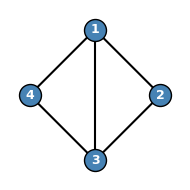

In [2]:
drawGraph(4, [(1, 2), (2, 3), (3, 4), (1, 4), (1, 3)])

**Def.:** a graph is **finite** if the cardinal of $V$ (and therefore also of $E$) is finite.

**Def.:** a graph is **numerable** if $V$ is a numerable set (i.e. if we can construct a bijection between an interval of $\mathbb N$ and $V$)

**Def.:** a graph is **complete** if all nodes are connected to each other.

**Theorem 1.1** a graph is complete $\Longleftrightarrow\boxed{card(E)=1+2+3+\ldots+n-1=\displaystyle\sum^{n-1}_{i=1}k=\frac{n(n-1)}{2}}$

**Proof:**

$\Longrightarrow$:

Let us take a node. It is connected to all $n-1$ other nodes, so we have $n-1$ different edges coming out of it. Now take any other node. It is also connected to $n-1$ nodes, but one of them we have already accounted for, so there are $n-2$ different edges coming out of it. The next selected node will have $2$ edges to be removed, so $n-3$ different edges coming out of it. Repeat until we eventually reach a node for which all the edges have already been accounted for (contributes with $0$). It is perhaps more intuitive to think of the procedure in reverse, hence the formula. The last equation is but the Gauss formula for the addition of the first $n-1$ natural numbers

$\Longleftarrow$:

Since the number of edges is saturated (maximum) for a simple graph (not multigraph), then the graph must be complete$_\blacksquare$

**Def.:** the **dimension** of a graph is defined as the cardinal of its set of vertices: $\boxed{dim G = card(V)\equiv n}$

# 2. Degree

**Def.:** the **degree** of a given vertex, $deg(v)$, is the number of edges connected to it

**Theorem 1.1 (reformulated)** a graph is complete $\Longleftrightarrow$ every vertex fulfills $deg(v)=n$



# 3. Matrix formulation

**Def.:** for a given graph, let us define the **adjacency matrix** $A$ as the $n$-dimensional square matrix whose $i$-th row represents the $i$-th node, and $j$-th column represents the $j$-th node. The matrix has a$+1$ entry if $i$ and $j$ are connected and $0$ if they are not. Since we are working with simple graphs, a node is never connected to itself, so the diagonal is 0

**Example:** the graph above can be represented through the matrix: $A=\begin{pmatrix}0&1&1&1\\1&0&1&0\\1&1&0&1\\1&0&1&0\end{pmatrix}$

**Defining properties:**
1. $A$ is square
2. $diag(A)=0$
3. The elements off the diagonal are $1$s and $0s$
4. $A$ is symmetric

**Theorem 3.1:** the adjacency matrix is symmetric: $A=A^T$

**Proof:**

If $i$ is connected to $j$, then $j$ is connected to $i$. Therefore, if $a_{ij}=1$ then $a_{ji}=1$. The same logic applies in the case they are not connected. Therefore, $a_{ij}=a_{ji}$ and the matrix is symmetric$_\blacksquare$

**Corollary:** the adjacency matrix has $\frac{n(n-1)}{2}$ independent (binary) entries

**Def.:** the **size** of a graph is defined as the number of bits needed to reconstruct the graph. Therefore, a graph of dimension $n$ has size $\boxed{\text{size}(G)=\frac{n(n-1)}{2} \ \text{bits}}$

**Proof:**

A symmetric matrix of dimension $n$ has $\frac{n(n+1)}{2}$ independent entries. Since ours is also traceless, that removes $n$ degrees of freedom, so we have $\frac{n(n+1)}{2}-n=\frac{n(n-1)}{2}$ independent entries$_\blacksquare$

**Proposition:** alternatively, the adjacency matrix can be defined in a more natural way as a skew-symmetric matrix with binary entries. This is more natural as the diagonals are immediately zero. If this is used, then the size of the graph coincides with the number of independent entries of its (skew-symmetric) adjacency matrix.

## Matrix $\leftrightarrow$ graph relation

**Theorem 3.2:** a graph $G$ has a unique adjacency matrix, and a given adjacency matrix represents a unique graph

**Proof:**

$G$ has a unique $A$: trivial, given a graph, two nodes either are connected or they are not, so the adjacency matrix is unique

$A$ has a unique $G$: again, trivial: a binary entry completely determines which pairs of nodes are connected. Again, this can't give rise to two different graphs$_\blacksquare$



**Corollary:** there is a one-to-one correspondence between the set of all $n$-dimensional graphs and the set of all $n$-dimensional adjacency matrices

**Corollary:** the former result allows us to determine the number of $n$-dimensional simple graphs we can build: $\boxed{2^{\text{size(G)}}}$

**Proof:**

1st is trivial

2nd: let us consider a simple grapg with $n$ nodes. Since the number of possible n-dimensional simple graphs is the same as the number of $n$-dimensional adjacency graphs, we can extract this number by the combinatorics of filling in the upper triangular matrix of $A$ with binary entries: the first independent entry has $2$ possible values. The upper row has two independent entries, so we have $2^2=4$ independent second rows, and so on until the uppermost row, which has $n-1$ indepdendent entries. Therefore, we have the combinatorics: $2\times 2^2\times\ldots\times 2^{n-1}=2^{1+2+\ldots+n-1}=2^{n(n-1)/2}=2^{\text{size}(G)}_\blacksquare$

**Example:** how many graphs can we build with 3 nodes?

1. Empty
2. Complete
3. Three with 1 edge
4. Three with 2 edges

These add up to 8. According to our formulas, the size of three-dimensional graphs is $3$ bits, and therefore we have $2^3=8$ possible graphs.

**Thinking about this the other way round:** let us formulate the problem the other way round. Up until now, we have known the number of nodes a graph has, and we have been concerned with how many different graphs we can produce by connecting (or not) each pair of nodes. However, our results are best understood if we formulate the question the other way around: I want to be able to generate $k$ different graphs. What is the least number of nodes that allow me to do this? Since each pair of nodes can be either connected or disconnected, we have $k=2^n$ possibilities. Naturally, if we choose $n$ to be very large (i.e. we use many nodes), the problem will surely be solved, quite trivially. However, if we choose the smallest $n$ such that it satisfies this condition, then we will have found the least dimension for which the problem has a solution

**Corollary:** if we want to be able to generate a number of graphs which is not a perfect power of $2$, then we need to choose the least number of vertices such that $k<2^n$. For instance, if we want to be able to generate $15$ combinations, we need to use $4$ nodes, which yield $16$ combinations, because with $3$ nodes we can't give rise to $15$ combinations, only $8$

## Graph Alphabet

**Proposition:** we can encode the alphabet using a square ($n=4$) graph (or greater)



**Proof:**

An $n=4$ graph has $\text{size}(G)=6$ bits. This allows for $2^6=64$ different combinations, thus encoding all $26$ letters. If we tried to use a lesser dimensional graph, such as a three-node graph, we could not achieve this: the three node graph has $3$ bits, allowing only for $8$ combinations$_\blacksquare$

**Example:**

A


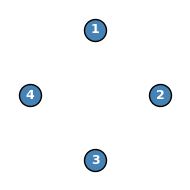

In [3]:
print("A")

drawGraph(4, [])

B, C, D, E, F, G


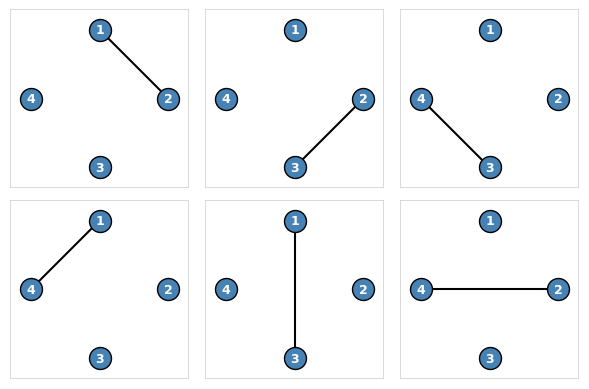

In [4]:
print("B, C, D, E, F, G")

drawGraph([4, 4, 4, 4, 4, 4], [[(1, 2)], [(2, 3)], [(3, 4)], [(4, 1)], [(1, 3)], [(2, 4)]])

H, I, J, K, L, M, N, O, P, Q, R, S, T


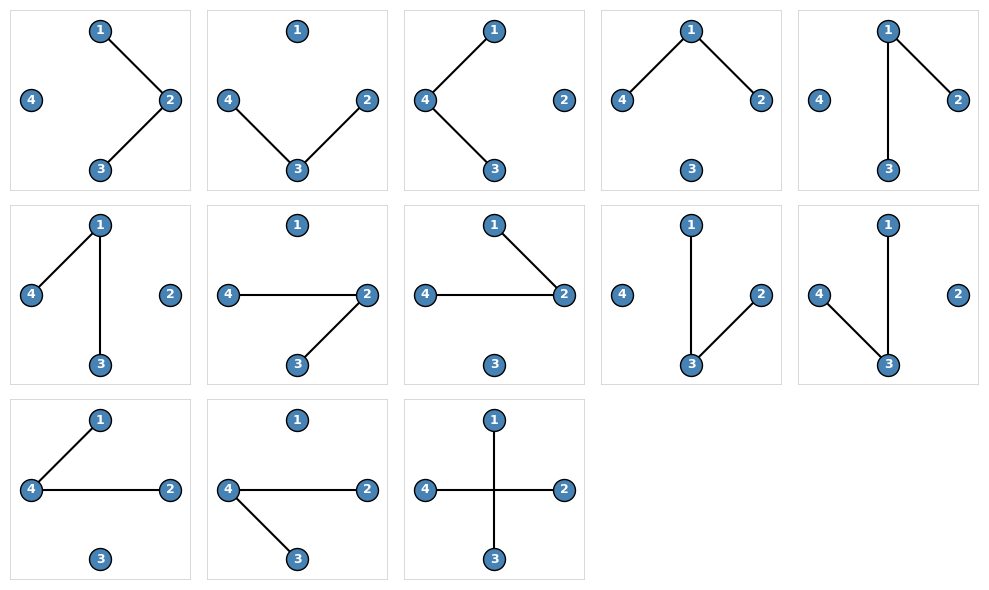

In [5]:
print("H, I, J, K, L, M, N, O, P, Q, R, S, T")

drawGraph([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], [[(1, 2), (2, 3)], [(2, 3), (3, 4)], [(3, 4), (4, 1)], [(4, 1), (1, 2)], [(1, 2), (1, 3)], [(1, 3), (1, 4)], [(2, 3), (2, 4)], [(2, 4), (2, 1)], [(3, 1), (3, 2)], [(3, 1), (3, 4)], [(4, 1), (4, 2)], [(4, 3), (4, 2)], [(1, 3), (2, 4)]])

U, V, W, X, Y, Z


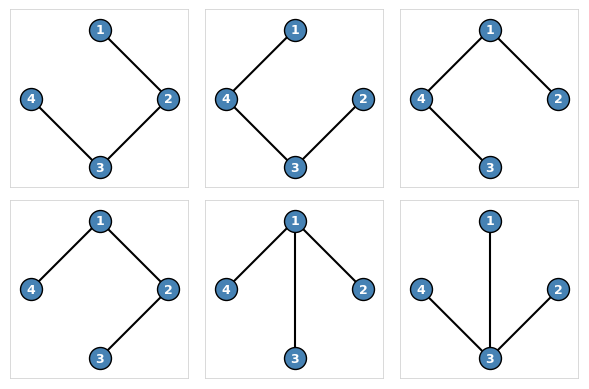

In [6]:
print("U, V, W, X, Y, Z")

drawGraph([4, 4, 4, 4, 4, 4], [[(1, 2), (2, 3), (3, 4)], [(2, 3), (3, 4), (4, 1)], [(1, 2), (3, 4), (4, 1)], [(1, 2), (2, 3), (4, 1)], [(1, 2), (1, 4), (1, 3)], [(2, 3), (3, 4), (3, 1)]])

**Example sentence:**

Hello


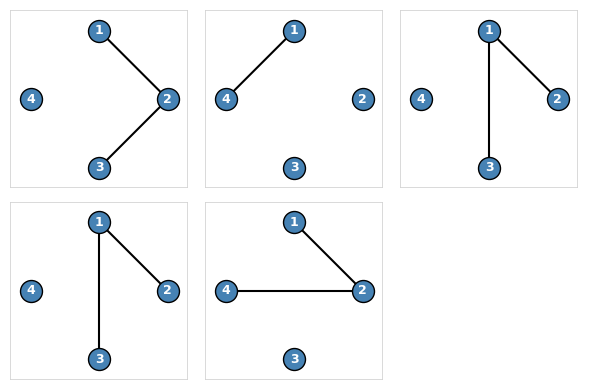

In [7]:
print("Hello")

drawGraph([4, 4, 4, 4, 4], [[(1, 2), (2, 3)], [(4, 1)], [(1, 2), (1, 3)], [(1, 2), (1, 3)], [(2, 4), (2, 1)]])

## Eigenvalues

**Proposition:** $A$ is diagonalizable and its spectrum is real and finite

**Proof:**

1. $A$ is symmetric, so it is diagonalizable and its spectrum is real (**this is not the case necessarily if we use a skew-symmetric matrix!**)
2. $det \ A=\lambda_1\ldots\lambda_n$ but the original matrix has only finite entries, so the determinant is also finite. Therefore, each eigenvalue is finite$_\blacksquare$

**Question:** what is the interpretation of these eigenvalues?

## Graph group

**Def.:** let $G$ be a simple graph. Let us build a graph $\bar G$ with the same dimension, where two vertices are connected if and only if they are not connected in $G$, and viceversa. This is to be called the "complementary" of a graph

**Proposition:** let $A$ be the adjacency matrix of $G$. The adjacency matrix of its complementary, $\bar A$, can be obtained as $\boxed{\bar A=Q-I-A}$, where $Q$ has all +1 entries. Equivalently, through bit-flipping $A$ (except its diagonal). Since it is an adjacency matrix, it is also unique

**Proof:**

It does what it says in the can: the complementary graph is obtained by a bit flip in every edge, meaning if a pair of nodes is connected, we disconnect it and vice versa. Performing a bit flip on the adjacency matrix (except the diagonal) means taking all the 0s off the diagonal and turning them into 1s and vice versa. The proposed computation has the intended effect, because $Q-I$ is a matrix with all 1s off the diagonal, and then: (1) where $a_{ij}=1$ we get $\bar a_{ij}=1-1=0$ and where $a_{ij=0}$ we get $\bar a_{ij}=1-0=1_\blacksquare$

**Def.:** let us define the "addition" of two n-dimensional graph as the sum of their adjacency matrices, modulo 2:

$$(A+B)_{ij}=(a_{ij}+b_{ij})\%2$$

Equivalently, this can be defined as:

$$A+B=\text{abs}(A-B)$$

**Theorem:** the set of all graphs of dimension $n$, alongside the addition operator, form an abelian finite group

**Proof:**

1. $\exists e$: $A=0$ (empty graph)
2. $\forall g\in H, \exists g^{-1}\in H $ tq. $gg^{-1}=g^{-1}g=e$: every graph is its own inverse, because $A+A=0$ (i.e. whichever edges were switched on are now off, and the ones that were off remain off as per our definition of sum)
3. $+$ is associative: trivial, it is matrix addition modulo 2.
4. The set of all $n$-dimensional graphs is closed under $+$: also yes, the addition of two adjacency matrices is also an adjacency matrix, as it fulfills: (1) it is a square matrix; (2) the diagonal is 0; (3) the off-diagonal elements are 0 or 1; (4) the matrix is symmetric because it is the subtraction of two symmetric matrices$_\blacksquare$

### Product table of $G_n$

**Proposition:** the binary relationship $G \sim G'$ if they have the same dimension is an equivalence relation, and hence it partitions the set of all simple graphs: $\{G\}=\{\{G_1\}, \ldots, \{G_n\}, \ldots\}; \ \ G_i\cap G_j=\emptyset$ unless $i=j$

**Proof:**

1. It is binary
2. Reflexion: $G\sim G$ because $n=n$
3. Symmetry: $G\sim G'\Longleftrightarrow G'\sim G$ because $n=n$
4. Transitivity: $G_1\sim G_2$ and $G_2\sim G_3$ then $G_1\sim G_3$ because $n_1=n_2$ and $n_2=n_3$ means $n_1=n_3$ $_\blacksquare$

**Proposition:** inside the set of all simple graphs of $dim(G)=n$, the binary relationship $G\sim G'$ if they have the same number of edges is an equivalence relation: $G\sim G'$ if $card(E)=card(E')$. Therefore, the set of all $n$-dimensional simple graphs can be partitioned by the number of edges of the graphs: $\{G_n\}=\{\{G(E=0)\}, \{G(E=1)\}, \ldots, \{G(E=n)\}\}$ ($G(E_i)$ is the n-dimensional graph with $E_i$ edges)

**Proof:**

1. It is binary
2. Reflexion: $card(E)=card(E)$
3. Symmetry: $card(E)=card(E)$
4. Transitivity: $card(E_1)=card(E_2)$ and $card(E_2)=card(E_3)$ means $card(E_1)=card(E_3)_\blacksquare$

**Example:** the set of all (8) graphs of dimension $n=3$ can be partitioned as:

$G(E=0)$:

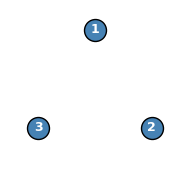

In [8]:
drawGraph(3, [])

$G(E=1)$:

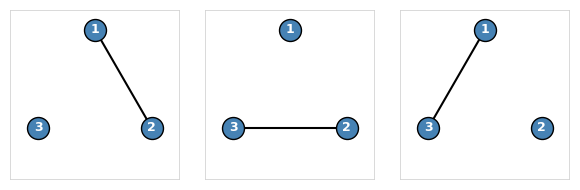

In [9]:
drawGraph([3, 3, 3], [[(1, 2)], [(2, 3)], [(3, 1)]])

$G(E=2)$:

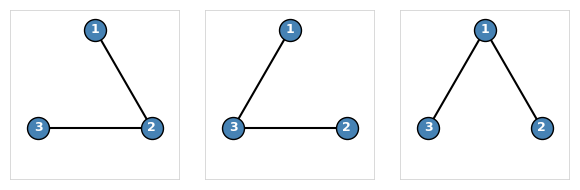

In [10]:
drawGraph([3, 3, 3], [[(1, 2), (2, 3)], [(2, 3), (3, 1)], [(3, 1), (1, 2)]])

$G(E=3)$:

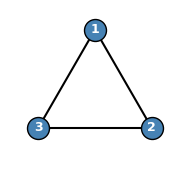

In [11]:
drawGraph(3, [(1, 2), (2, 3), (3, 1)])

**Caution:** it may appear from this example that the elements inside a same equivalence class are related by symmetry. However, this is not the case necessarily, confront:

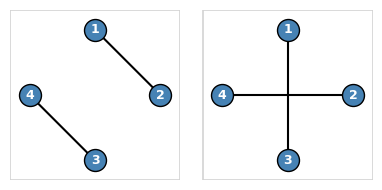

In [12]:
drawGraph([4, 4], [[(1, 2), (3, 4)], [(1, 3), (2, 4)]])

### Group table for $(G, +)$

Let us now build the product table of some low-dimensional graphs to attempt to see a pattern, because in principle it is not trivial to determine what group $G_n$ forms under addition defined as above. What we can tell at this stage is:

1. The groups are finite
2. The groups are abelian
3. The groups are NOT cyclic (because $g^2=e; \ \forall g \in G$), except for $n=2$, which has no other choice because it has $2$ elements (graphs)

In [101]:
from itertools import product, combinations

def makeAs(n):
    """
    Generate all n x n matrices with:
      - zero diagonal
      - symmetric (M[i,j] = M[j,i])
      - entries in {0,1}
    Yields 2^(n(n-1)/2) matrices.
    """
    upper_positions = list(combinations(range(n), 2))  # (i,j) with i<j
    m = len(upper_positions)  # = n(n-1)/2

    for bits in product([0, 1], repeat=m):
        M = np.zeros((n, n), dtype=int)
        for (i, j), b in zip(upper_positions, bits):
            M[i, j] = b
            M[j, i] = b
        yield M
        
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def build_product_table(matrices):
    n = matrices[0].shape[0]
    zero_mat = np.zeros((n, n), dtype=int)
    complete_mat = 1 - np.eye(n, dtype=int)

    e_idx = next(i for i, M in enumerate(matrices) if np.array_equal(M, zero_mat))
    k_idx = next(i for i, M in enumerate(matrices) if np.array_equal(M, complete_mat))

    rest = [i for i in range(len(matrices)) if i not in (e_idx, k_idx)]
    order = [e_idx] + rest + [k_idx]

    ordered_matrices = [matrices[i] for i in order]
    # Mathtext subscripts: $A_{1}$ renders as A with a subscript 1
    labels = ["$e$"] + [f"$A_{{{i}}}$" for i in range(1, len(rest) + 1)] + [f"$K_{{{n}}}$"]

    m = len(ordered_matrices)
    lookup = {M.tobytes(): idx for idx, M in enumerate(ordered_matrices)}

    table = np.full((m, m), -1, dtype=int)
    for i in range(m):
        for j in range(i, m):
            prod = (ordered_matrices[i] + ordered_matrices[j]) % 2
            k = lookup[prod.tobytes()]
            table[i, j] = k
            table[j, i] = k

    return ordered_matrices, labels, table


def plot_product_table(labels, table, title="Product Table"):
    m = len(labels)
    cmap = ListedColormap(plt.cm.tab20.colors[:m] if m <= 20 else plt.cm.viridis(np.linspace(0, 1, m)))
    cmap.set_bad("white")

    cell_size = 0.2  # smaller cells -> smaller overall figure
    fig, ax = plt.subplots(figsize=(1.5 + m * cell_size, 1.5 + m * cell_size), dpi=120)

    display_table = np.ma.masked_array(table, mask=np.tril(np.ones_like(table), k=-1))
    ax.imshow(display_table, cmap=cmap, vmin=0, vmax=m - 1)

    fontsize = max(6, 11 - m // 3)  # shrink text as table grows
    for i in range(m):
        for j in range(i, m):
            ax.text(j, i, labels[table[i, j]], ha="center", va="center",
                     fontsize=fontsize, fontweight="bold", color="black")

    ax.set_xticks(range(m)); ax.set_xticklabels(labels, fontsize=fontsize)
    ax.set_yticks(range(m)); ax.set_yticklabels(labels, fontsize=fontsize)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, m, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(which="major", length=0)

    ax.set_title(title, fontsize=fontsize + 2, pad=10)
    fig.tight_layout()
    plt.show()

def checkSubgroup(As):
    s = {A.tobytes() for A in As}
    for A in As:
        transformed = (A + As) % 2
        if {t.tobytes() for t in transformed} != s:
            return False
    return True



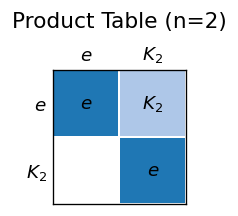

In [14]:
n = 2
matrices = list(makeAs(n))
ordered_matrices, labels, table = build_product_table(matrices)
plot_product_table(labels, table, title=f"Product Table (n={n})")

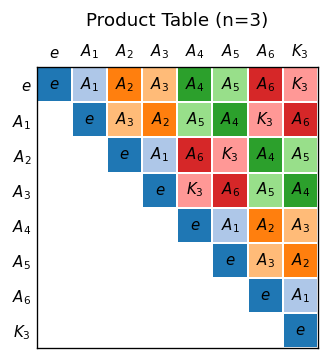

In [15]:
n = 3
matrices = list(makeAs(n))
ordered_matrices, labels, table = build_product_table(matrices)
plot_product_table(labels, table, title=f"Product Table (n={n})")

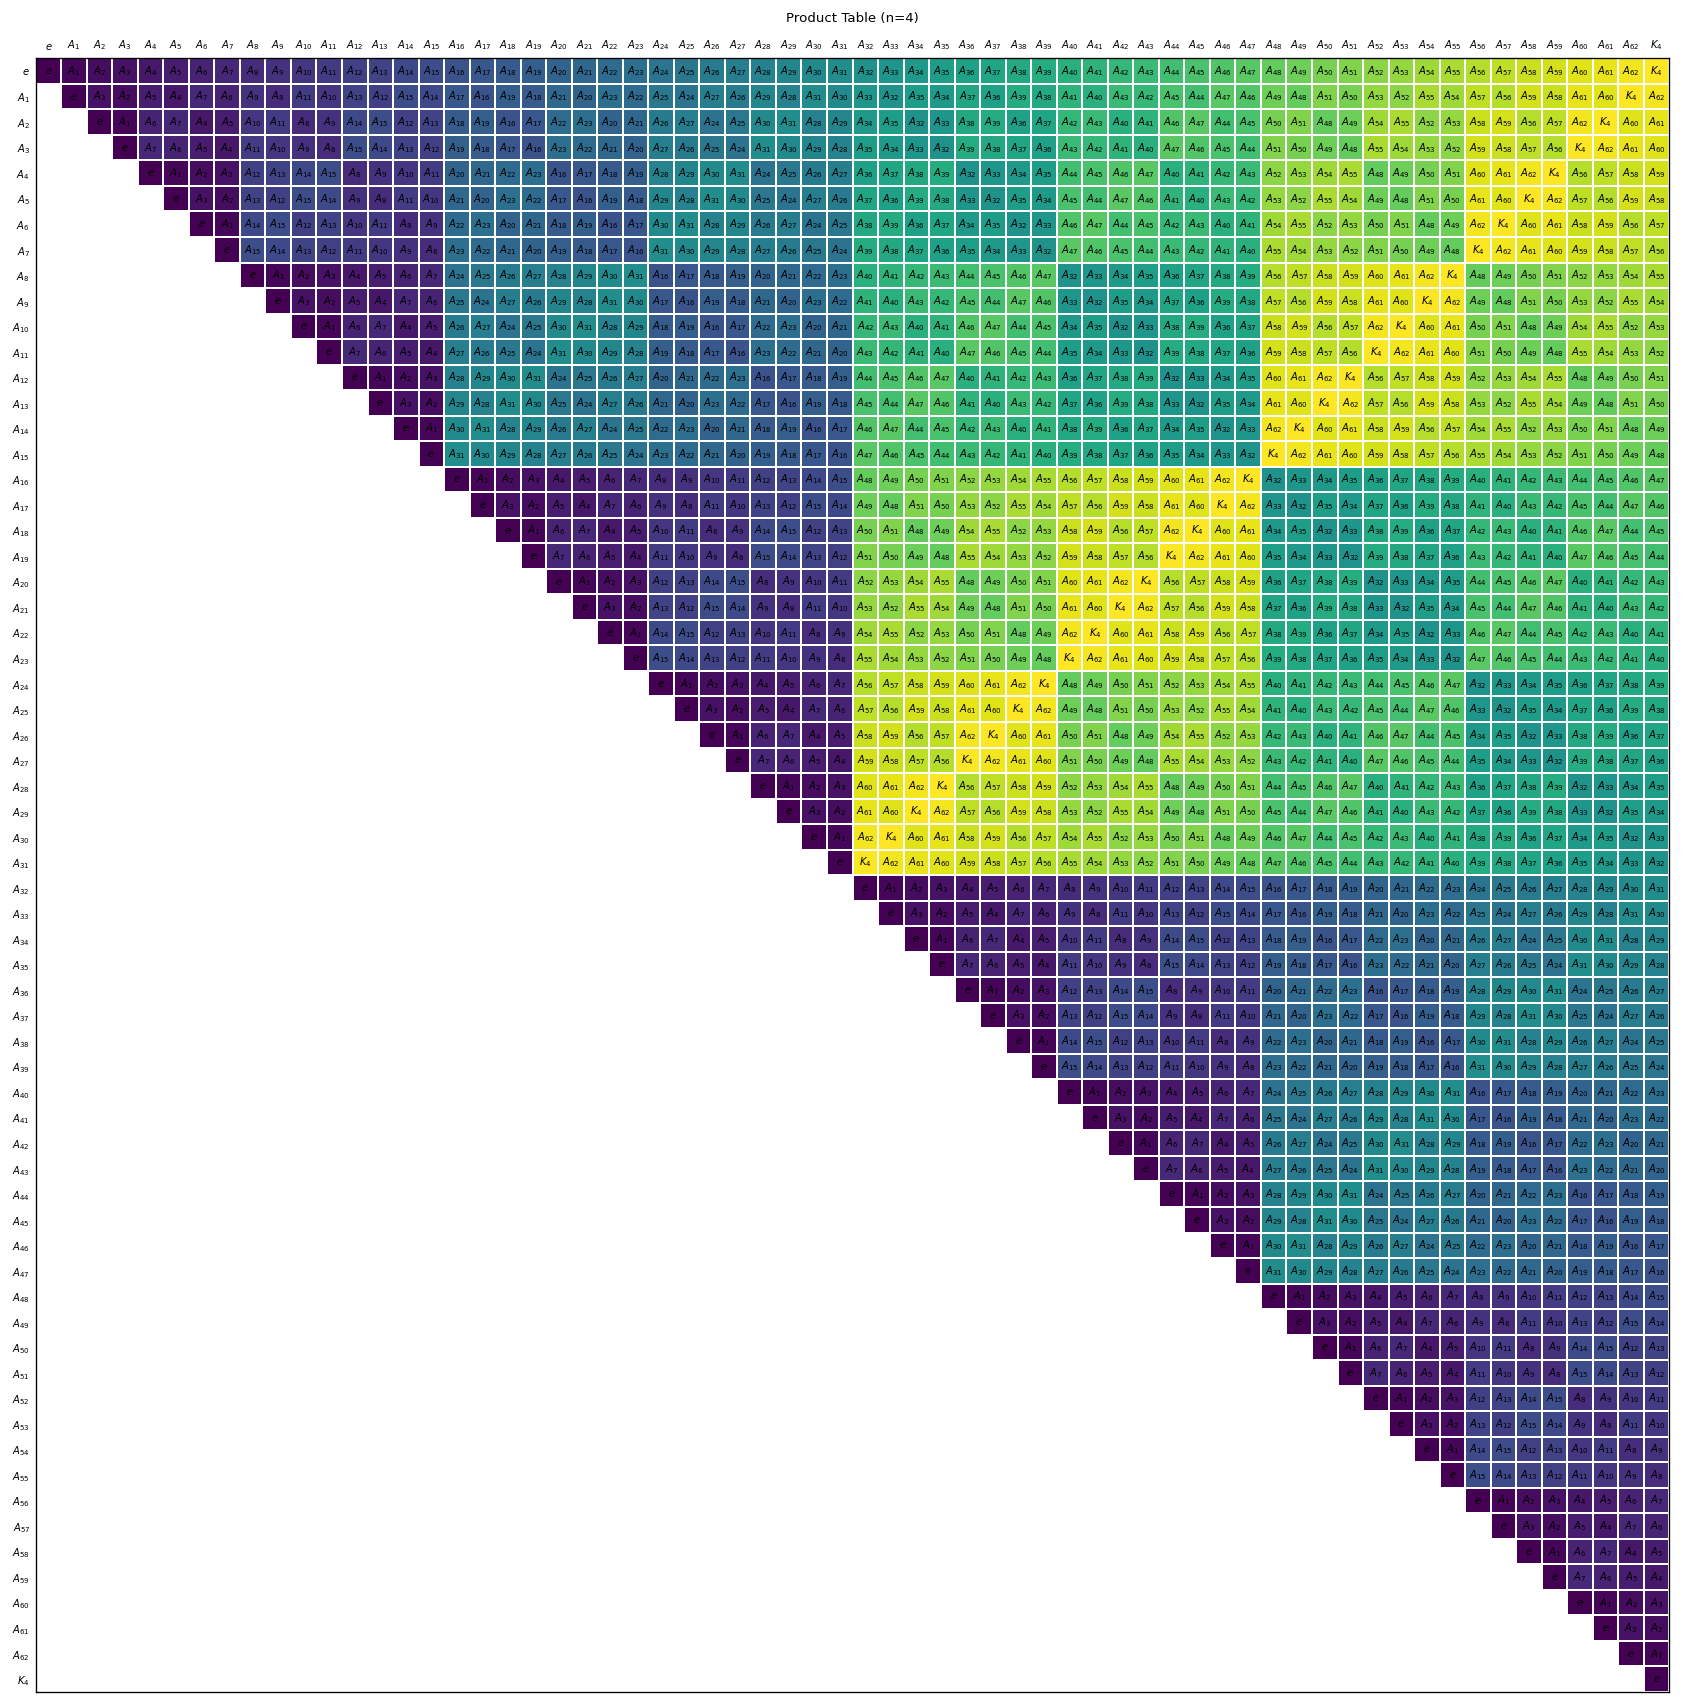

In [16]:
n = 4
matrices = list(makeAs(n))
ordered_matrices, labels, table = build_product_table(matrices)
plot_product_table(labels, table, title=f"Product Table (n={n})")

**Observation:** $G_2$ is $C_2$

**Observation:** $G_3$ is $C_2\times C_2 \times C_2$

**Central theorem of graph groups:** the group of $n$-dimensional graphs is $\boxed{G_n\cong (\mathbb Z_2)^{n(n-1)/2}}$

## $G_n$ as a group

Let us study more in detail the group structure of $G_n$, as in doing so we will be studying the subgroups formed by the $n$-dimensional graphs under binary addition. This is interesting on its own, but it will also find many applications in upcoming sections. For instance, group homomorphisms link exclusively subgroups of the domain to subgroups of the codomain. Since the groups under consideration are finite, their subgroups can in turn be represented as nodes which are connected if the homomorphsim links one to another: a graph!

### Group homomorphism theorems

**Theorem:** let $f:G\to G'$ be a group homomorphism. Then, $\ker f\trianglelefteq G$ and $Im f<G'$ 

**Proof:**

Kernel: this statement about the kernel will be true if and only if it satisfies the definition of a normal subgroup: $\forall h\in H, \ \exists g\in G$ tq. $g^{-1}h g\in H$

Is $\ker f<G$?: Yes. Let $g, g'\in \ker f$.

1. $\odot_G$ is associative? Yes
2. $\exists g^{-1}$?, i.e., $f(g)=e\Longleftrightarrow g(g^{-1})=e$? Yes, because $f(g^{-1}g)=f(g^{-1})e$ but also $=f(e)=e$, so $f(g^{-1})=e$
3. $\exists e$?: Yes, trivially, homomorphisms map $f(e)=e$
4. Is it closed under $\odot_G$?: Yes, $f(gg')=f(g)f(g')=e$, so $g, g'\in \ker f\Longrightarrow gg'\in \ker f$

So indeed $\ker f\leq G$. Now let us test if it is a normal subgroup of $G$. Let $h\in \ker f$ and $g\in G$, not necessarily in the kernel. Then:

$f(g^{-1}hg)=f(g^{-1})f(h)f(g)=f(g^{-1})ef(g)=f(e)=e$, so $g^{-1}hg\in \ker f$, and therefore $\ker f\trianglelefteq G$

Image: let us test the subgroup conditions again:

1. $\odot_{G'}$ is associative?
2. $\exists g^{-1}$?, i.e. $\exists f^{-1}(g) \ \ \forall f(g)\in Im f$? Yes: $f^{-1}(g)=f(g^{-1})$ because $f^{-1}(g)f(g)=e$ and $f(g^{-1})f(g)=f(e)=e$
3. $\exists e$?: Yes, $e_{G'}=f(e)$
4. Is it closed under $\odot_{G'}$, i.e. $f(g)f(g')\in Im f$? Yes, $f(g)f(g')=f(gg')\in Im f$ by hypothesis

Therefore, $Im f\leq G'$. Note that it is not necessarily a normal subgroup of $G'$: let $g\in G'$, $h\in Im f$. Let us rewrite $h=f(t), t\in G$. $g^{-1}f(t)g$, which is not in the image necessarily, unless $g$ is also mapped by the application: $g=f(w), w\in G_\blacksquare$

**Theorem:** $G$ abelian $\Longrightarrow$ all of its subgroups are normal ($H\trianglelefteq G$)

**Proof:**

Let $H\leq G$. Let us test if it is indeed a normal subgroup. Let $h\in H$ and $g\in G$. Then, $g^{-1}hg=h\in H$ and hence $H\trianglelefteq G_\blacksquare$

**Theorem:** group homomorphisms map subgroups of the domain to subgroups of the codomain

**Proof:**

This statement will be proved if we show that, for every $g, g'\in W\leq G$, they map to $f(g), f(g')\in W'\leq G'$, and that no other element of $G$ maps to $W'$.

If $W\leq G$, is $f(W)$ a group?

1. $\odot_{G'}$ is associative?: Yes
2. $\exists f^{-1}(g)$?: Yes, $f^{-1}(g)\equiv f(g^{-1})$
3. $\exists e$?: Yes, $f(e)$
4. Is $f(W)$ closed under $\odot_{G'}$?: $f(w)f(w')=f(ww')$, but $ww'\in W$, so $f(w)f(w')\in f(W)$

More directly, we could notice: (1) subgroups of the codomain are groups themselves; (2) the image of group homomorphism is a subgroup of the codomain. (3) Therefore, if we define the "reduced homomorphism" $\tilde f: W\to G'$, we see that $f(W)\leq G'$ necessarily$_\blacksquare$

### Subgroup structure of $G_n$

Let us study the subgroup structure of $G_n$

**Proposition:** according to Lagrange's theorem, groups can only have $k$-dimensional subgroups, where $k$ divides $n$. Therefore, $G_n\cong \mathbb Z_2^{n(n-1)/2}$, which has dimension $2^{n(n-1)/2}$, can only have (improper) subgroups whose dimension is a perfect power of $2$:

$$\boxed{W_n\leq G_n \Longrightarrow dim(W_n)=2^k, \ \ k\in \left\{1, \ldots, \frac{(n+1)(n-2)}{2}\right\}}$$

**Example:** the graph group $G_3$ can only have $2$- and $4$-dimensional subgroups

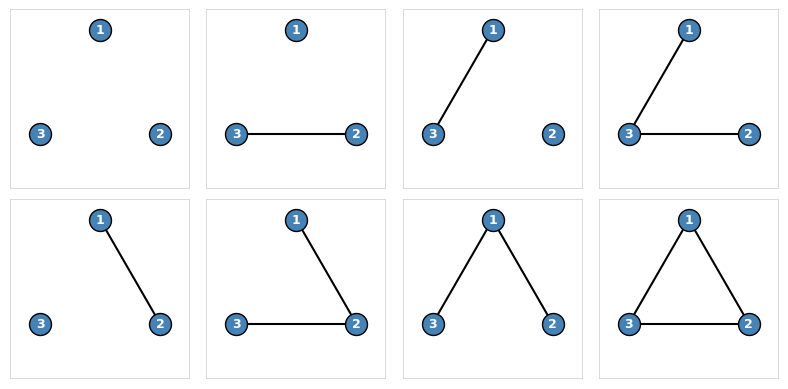

In [96]:
As = list(makeAs(3))

graphAs(As)

**Subgroup structure of $G_3$:**

1. $W_1=\{e\}$
2. $W_2\cong \mathbb Z_2=\{e, g_i\}$: 7 (every graph is its inverse, but $\{e,e\}$ is not a group in that it repeats an element)
3. $W_4\cong \mathbb Z_4=\{e, \}$

**Note:** for 

In [125]:
import itertools
from collections import defaultdict
import numpy as np


def get_upper_tri_vector(matrix):
    """Extracts upper triangular entries into a 1D vector (dim m = n(n-1)/2)."""
    n = len(matrix)
    indices = np.triu_indices(n, k=1)
    return matrix[indices]


def rref_f2(matrix):
    """Computes Reduced Row Echelon Form over F_2 to identify unique subspaces."""
    mat = np.array(matrix, dtype=int) % 2
    rows, cols = mat.shape
    pivot_row = 0
    pivot_cols = []

    for c in range(cols):
        p = pivot_row
        while p < rows and mat[p, c] == 0:
            p += 1
        if p == rows:
            continue

        mat[[pivot_row, p]] = mat[[p, pivot_row]]
        pivot_cols.append(c)

        for r in range(rows):
            if r != pivot_row and mat[r, c] == 1:
                mat[r] = (mat[r] + mat[pivot_row]) % 2

        pivot_row += 1
        if pivot_row == rows:
            break

    return mat[:pivot_row], pivot_cols


def find_subgroups_by_order(As, min_k=2):
    """Finds all subgroups grouped by their order 2^k.

    Parameters:
    - As: List of n x n adjacency matrices (numpy arrays or nested lists)
    - min_k: Minimum basis dimension (default 2, corresponding to order 4,
      excluding Z_2)

    Returns:
    - dict: { order (int): [ subgroup_1, subgroup_2, ... ] }
      where each subgroup is a list of matrices from `As`.
    """
    n = len(As[0])
    m = n * (n - 1) // 2

    # Map matrices in As to 1D upper-triangular vectors
    vectors = [get_upper_tri_vector(np.array(A)) for A in As]

    # Quick lookup mapping vector tuples back to exact matrix objects from As
    vec_to_matrix = {tuple(v): A for v, A in zip(vectors, As)}

    # Dictionary to store subgroups keyed by order: {2^k: [list of subgroups]}
    subgroups_dict = defaultdict(list)
    seen_canonical_bases = set()

    # Loop over dimension k (Order = 2^k)
    for k in range(min_k, m):
        order = 2**k

        for combo in itertools.combinations(vectors, k):
            rref_basis, pivot_cols = rref_f2(combo)

            # Check linear independence (rank == k)
            if len(pivot_cols) == k:
                # Unique signature for the vector space
                key = tuple(map(tuple, rref_basis))

                if key not in seen_canonical_bases:
                    seen_canonical_bases.add(key)

                    # Generate all 2^k elements of the subspace
                    subgroup_matrices = []
                    for r in range(k + 1):
                        for subset in itertools.combinations(rref_basis, r):
                            if not subset:
                                sum_vec = np.zeros(m, dtype=int)
                            else:
                                sum_vec = np.bitwise_xor.reduce(subset)

                            subgroup_matrices.append(
                                vec_to_matrix[tuple(sum_vec)]
                            )

                    # Add this subgroup to the corresponding order key
                    subgroups_dict[order].append(subgroup_matrices)

    # Convert to normal dict with standard key sorting
    return dict(sorted(subgroups_dict.items()))


# --- Usage ---
# Assuming 'As' is your list of matrices:
subgroups_by_order = find_subgroups_by_order(As, min_k=1)

# Inspect the dictionary layout:
for order, subgroups in subgroups_by_order.items():
    print(f"Order {order}: {len(subgroups)} subgroup(s) found.")

Order 2: 7 subgroup(s) found.
Order 4: 7 subgroup(s) found.


**TODO:** modify the generate table function so that it allows for elements of any dimension, not just full groups

# Walks

**Def.:** given a graph $G$, a "walk" is a sequence of connected nodes. The walk will be "closed" if the starting node coincides with the final one

$$\boxed{W :=\{v_1, \ldots, v_k\} \subset V(G) \text{ tq. } v_iv_{i+1}\in E(G)}$$

****

# Graph statistics

Define hub and do relevance as "from all edges in the graph, percentage of edges that connect to that node". Another nonequivalent definition is "add up all the degrees and take the relevance as d_i/sum d_i"

**Def.:** given a graph $G$, let us define the **degree** of a node as the number of edges of the graph that pass through that node. The **fractional degree** of a node, $X(v)$, shall be its degree over the sum of all degrees:

$$\boxed{X(v_i):=\frac{d_i}{\displaystyle\sum_{i=1}^n d_i}}$$

**Notice:** the total fractional degree of a graph is normalized to 1, which opens the gate to thinking about the fractional degree of each node as its relevance in the graph. This should be particularly relevant in networks, where the fractional degree would help determine hubs, isolated nodes, etc.

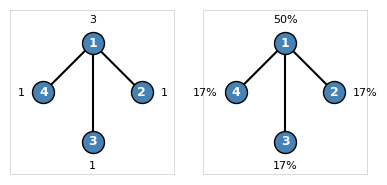

In [17]:
drawGraph([4, 4], [[(1, 2), (1, 4), (1, 3)], [(1, 2), (1, 4), (1, 3)]], labels=[["3", "1", "1", "1"], ["50%", "17%", "17%", "17%"]])

**Proposition:** the maximum fractional degree a node can have is $50\%$

**Proof:**

Let us consider the setting for a graph of dimension $n$ such that node $v$ has the greatest possible fractional degree. This would happen when the numerator (i.e. its degree) is maximized (the node is connected to every other node, so $deg(v)=n-1$) and the denominator is minimized (i.e. the sum of all degrees is minimized, so every other node is only connected to $v$). Therefore, $X(v)=\frac{n-1}{(n-1)_v+\displaystyle\sum_{i\neq v}^{n} 1}=\frac{1}{2}$. Even more directly, using the handshake lemma we know since there are $n-1$ edges the total degree of the graph must be $2(n-1)$, and again we obtain $\frac{1}{2}_\blacksquare$

### Histogram of fractional degrees

When working with small graphs, the fractional degrees are readily seen in the graphical representations. However, if we were working with a thousand nodes, we would hardly see anything at all, and it would be very hard to compare the fractional degrees of different nodes. A good way to visualize this even for large nodes is through a histogram, where each node is assigned its corresponding number, and the heightt of its bar corresponds to its fractional degree

In [18]:
def drawHist(values, chunk_size=37, ref_line=0.25, ascending=False):
    n = len(values)
    nodes = np.arange(1, n + 1)

    order = np.argsort(values)[::-1] if not ascending else np.argsort(values)
    sorted_values = values[order]
    sorted_nodes = nodes[order]

    # Split into chunks of `chunk_size`
    n_chunks = math.ceil(n / chunk_size)
    chunks_values = [sorted_values[i*chunk_size:(i+1)*chunk_size] for i in range(n_chunks)]
    chunks_nodes = [sorted_nodes[i*chunk_size:(i+1)*chunk_size] for i in range(n_chunks)]

    # Grid layout, same spirit as the graph-drawing code
    rows = math.floor(math.sqrt(n_chunks))
    cols = math.ceil(n_chunks / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, chunk_size * 0.18 * rows))
    axes_list = [axes] if n_chunks == 1 else np.array(axes).reshape(-1)

    for i in range(n_chunks):
        ax = axes_list[i]
        cv, cn = chunks_values[i], chunks_nodes[i]
        k = len(cv)

        ax.barh(range(k), cv, height=0.7, edgecolor="black", color="steelblue")
        ax.axvline(ref_line, color="red", linewidth=1.2, zorder=3)
        ax.set_yticks(range(k))
        ax.set_yticklabels(cn)
        ax.set_ylabel("Node")
        ax.set_xlabel("X(node)")
        ax.invert_yaxis()
        ax.set_title(f"Rank {i*chunk_size + 1}\u2013{i*chunk_size + k}", fontsize=10)

    # Hide unused subplot slots
    for j in range(n_chunks, len(axes_list)):
        axes_list[j].axis("off")

    plt.tight_layout()
    plt.show()

**Example:** relative degree histogram of arrow graph:

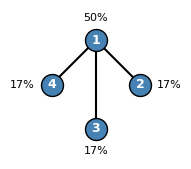

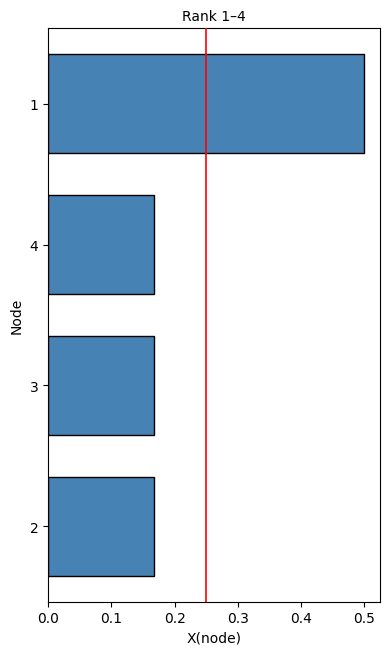

In [19]:
drawGraph(4, [(1, 2), (1, 4), (1, 3)], labels=["50%", "17%", "17%", "17%"])

drawHist(np.array([1/2, 1/6, 1/6, 1/6]))

**Proposition:** since a graph $G$ is completely equivalent to its adjacency matrix (in that this matrix contains all the information of the graph and vice versa), we can recover the degree (and relative degree) from said matrix:

$$deg(v_i)=\displaystyle\sum_{j=1}^n a_{ij}$$

$$X(v_i)=\frac{deg(v_i)}{\sum deg(v_i)}=\frac{\displaystyle\sum_{j=1}^n a_{ij}}{\displaystyle\sum_{i,j=1}^n a_{ij}}$$

In [20]:
def getD(A):
    diag = []
    for row in A:
        diag.append(np.sum(row))
    return np.diag(diag)


def getX(A):
    D = getD(A)
    return np.diag(D/np.sum(np.diag(D)))

def getA(n, E):
    # Returns A of a graph, given as E(G)
    A = np.zeros((n,n), dtype="int")
    for idx in E:
        A[idx[0]-1, idx[1]-1]=1
        A[idx[1]-1, idx[0]-1]=1
    return A

**Util:** given a graph (or its adjacency matrix), we can now calculate its relative degree histogram.

**Example:** arrow graph (again, this time automated, i.e. without having to introduce the Xs by hand)

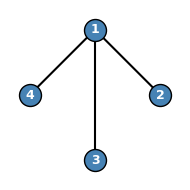

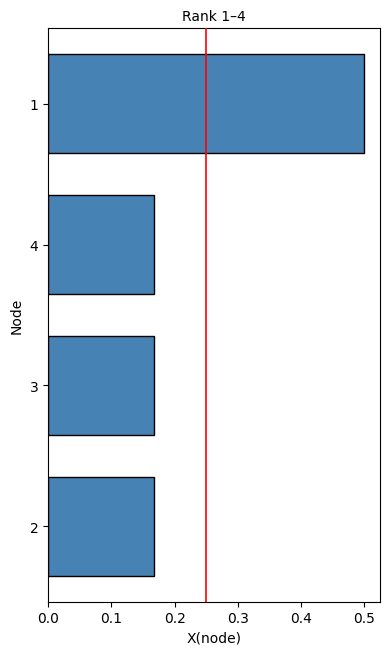

In [21]:
A = getA(4, [(1, 2), (1, 3), (1, 4)])
graphAs([A])
drawHist(getX(A))

# Multigraphs and reduction

In [33]:
import math
import matplotlib.pyplot as plt
import numpy as np


def _bezier_arc_points(x1, y1, x2, y2, curvature, n_points=30):
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    dx, dy = x2 - x1, y2 - y1
    length = math.hypot(dx, dy)
    if length == 0:
        return np.array([x1]), np.array([y1])
    px, py = -dy / length, dx / length
    cx, cy = mx + px * curvature * length, my + py * curvature * length

    t = np.linspace(0, 1, n_points)
    bx = (1 - t) ** 2 * x1 + 2 * (1 - t) * t * cx + t ** 2 * x2
    by = (1 - t) ** 2 * y1 + 2 * (1 - t) * t * cy + t ** 2 * y2
    return bx, by


def _draw_multi_edge(ax, x1, y1, x2, y2, mult, base_curvature=0.15, zorder=1):
    if mult == 1:
        curvatures = [0.0]
    else:
        curvatures = np.linspace(-base_curvature * (mult - 1) / 2,
                                   base_curvature * (mult - 1) / 2, mult)
    for c in curvatures:
        bx, by = _bezier_arc_points(x1, y1, x2, y2, c)
        ax.plot(bx, by, color="black", linewidth=1.5, zorder=zorder)


def _normalize_edgesM(E):
    """Accept (u,v) or (u,v,mult) tuples; return list of (u,v,mult)."""
    out = []
    for e in E:
        if len(e) == 2:
            u, v = e
            out.append((u, v, 1))
        else:
            u, v, mult = e
            out.append((u, v, mult))
    return out


def _draw_bundle_box(ax, pos, u, v, mult, bundle_number,
                      base_curvature=0.15, length_frac=0.4, pad=0.06, number_offset=0.09):
    """Draw a red rectangle around part of the (u,v) edge bundle, with its number
    placed just outside, on the side facing away from the graph's center."""
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    dx, dy = x2 - x1, y2 - y1
    length = math.hypot(dx, dy)
    if length == 0:
        return
    ux, uy = dx / length, dy / length      # unit vector along the edge
    px, py = -uy, ux                       # perpendicular unit vector

    mx, my = (x1 + x2) / 2, (y1 + y2) / 2  # midpoint of the segment

    half_len = length * length_frac / 2
    if mult > 1:
        half_width = base_curvature * (mult - 1) / 2 * length + pad
    else:
        half_width = pad  # mult == 0 (bundle "doesn't exist") or mult == 1 -> thin box

    # Rectangle corners (symmetric about the segment, aligned with its direction)
    corners = [
        (mx - half_len * ux - half_width * px, my - half_len * uy - half_width * py),
        (mx + half_len * ux - half_width * px, my + half_len * uy - half_width * py),
        (mx + half_len * ux + half_width * px, my + half_len * uy + half_width * py),
        (mx - half_len * ux + half_width * px, my - half_len * uy + half_width * py),
    ]
    rect = plt.Polygon(corners, closed=True, fill=False,
                        edgecolor="red", linewidth=1.5, zorder=5)
    ax.add_patch(rect)

    # Pick the perpendicular direction pointing away from the graph's center (0,0),
    # so the label sits on the "outside" rather than toward the middle of the graph.
    if mx * px + my * py < 0:
        px, py = -px, -py

    label_x = mx + (half_width + number_offset) * px
    label_y = my + (half_width + number_offset) * py
    ax.text(label_x, label_y, str(bundle_number), color="red", fontsize=9,
            fontweight="bold", ha="center", va="center", zorder=6)


def _normalize_bundles(bundles):
    """Accept a list of (u,v) pairs (auto-numbered 1,2,...) or a dict {(u,v): number}."""
    if bundles is None:
        return {}
    if isinstance(bundles, dict):
        return {tuple(k): v for k, v in bundles.items()}
    return {tuple(pair): i + 1 for i, pair in enumerate(bundles)}


def _draw_single_graphM(ax, n, E, border=False, size=2, labels=None, label_offset=0.38,
                        bundles=None):
    angles = np.pi / 2 - 2 * np.pi * np.arange(n) / n
    xs = np.cos(angles)
    ys = np.sin(angles)
    pos = {i + 1: (xs[i], ys[i]) for i in range(n)}

    edges = _normalize_edgesM(E)
    mult_lookup = {}
    for (u, v, mult) in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        _draw_multi_edge(ax, x1, y1, x2, y2, mult)
        mult_lookup[tuple(sorted((u, v)))] = mult

    node_x = [pos[i][0] for i in pos]
    node_y = [pos[i][1] for i in pos]
    ax.scatter(node_x, node_y, s=250, color="steelblue", edgecolor="black", zorder=2)

    for label, (x, y) in pos.items():
        ax.text(x, y, str(label), ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold", zorder=3)

    if labels is not None:
        for i in range(n):
            lx = xs[i] * (1 + label_offset)
            ly = ys[i] * (1 + label_offset)

            ha = "left" if xs[i] > 0.15 else "right" if xs[i] < -0.15 else "center"
            va = "bottom" if ys[i] > 0.15 else "top" if ys[i] < -0.15 else "center"

            ax.text(lx, ly, str(labels[i]), ha=ha, va=va,
                     color="black", fontsize=8, zorder=4)

    # Bundle boxes + numbers (drawn last -> on top of everything else)
    bundle_dict = _normalize_bundles(bundles)
    for (u, v), number in bundle_dict.items():
        mult = mult_lookup.get(tuple(sorted((u, v))), 0)
        _draw_bundle_box(ax, pos, u, v, mult, number)

    ax.set_aspect("equal")
    lim = 1.3 + (label_offset if labels is not None else 0)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axis("off")
    if border:
        ax.add_patch(plt.Rectangle(
            (-lim, -lim), 2 * lim, 2 * lim,
            fill=False, edgecolor="lightgray", linewidth=1.2, zorder=0,
        ))


def drawMultigraphs(n, E, separators=True, size=2, labels=None, bundles=None):
    """
    n, E, separators, size, labels : as before.
    bundles : list of (u,v) pairs (auto-numbered 1,2,...) or dict {(u,v): number},
              or a list of such (one per graph) when drawing several graphs.
              Pairs need not have an actual edge -- the box is drawn regardless.
    """
    if isinstance(n, int):
        n_list = [n]
        E_list = [E]
        labels_list = [labels] if labels is not None else [None]
        bundles_list = [bundles] if bundles is not None else [None]
    else:
        n_list = list(n)
        E_list = list(E)
        if len(n_list) != len(E_list):
            raise ValueError("n and E must have the same length when drawing multiple graphs.")
        labels_list = labels if labels is not None else [None] * len(n_list)
        bundles_list = bundles if bundles is not None else [None] * len(n_list)

    k = len(n_list)
    rows = math.floor(math.sqrt(k))
    cols = math.ceil(k / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows))

    axes_list = [axes] if k == 1 else np.array(axes).reshape(-1)

    for i in range(k):
        _draw_single_graphM(axes_list[i], n_list[i], E_list[i],
                            border=(k > 1 and separators),
                            labels=labels_list[i], bundles=bundles_list[i])

    for j in range(k, len(axes_list)):
        axes_list[j].axis("off")

    plt.tight_layout()
    plt.show()


def drawMultiAs(As, labels=None, bundles=None):
    n = As[0].shape[0]
    edges = []
    for A in As:
        rows, cols = np.triu_indices(n, k=1)
        mask = A[rows, cols] > 0
        r, c, m = rows[mask] + 1, cols[mask] + 1, A[rows, cols][mask]
        edges.append(list(zip(r, c, m)))
    drawMultigraphs([n for _ in range(len(As))], edges, labels=labels, bundles=bundles)

**Def.:** a "multigraph" is a graph where the nodes are allowed to connect more than once to other nodes

**Proposition:** a multigraph can be written as a simple graph, with the addition of a numeric label on each edge giving the count of how many times the two nodes connect. This is to be called the "degree" of the edge, $deg(v_iv_j)$. The set of edges connecting the same pair of nodes are called a "bundle"

**Proposition:** the degree of a node is the sum of the degrees of the edges connected to it

**Proposition:** the adjacency matrix can be generalized naturally to multigraphs. The interpretation is the same, but now the entries can be any natural number, or 0 (i.e. the count of the edges)

**Proposition:** since the edges have a count, we can think of them as nodes and of the nodes as edges: take a multigraph $M$. Take the bundle connecting nodes $v_i, v_j$. In a separate  graph, $\tilde M$, draw a node for that bundle, where its degree is the degree of the bundle $v_iv_j$. In this new graph, two bundle nodes will be connected if they touch the same node in the original graph. They shall be connected by a bundle of degree the degree of the original node they touch. If there are three or more bundles connecting to a node, there is an ambiguity in the repartition of the new edges. In this case, let the prescription be to take the sum of edges in the original graph for every pair (i.e. treat every node as if it had only two bundles connected to it, for every pair of bundles)

**Example:**

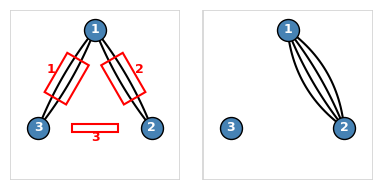

In [23]:
drawMultigraphs([3, 3], [[(1, 2, 2), (1, 3, 2)], [(1, 2, 4)]], bundles=[[(1, 3), (1,2), (2, 3)], []])

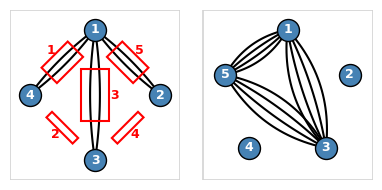

In [24]:
drawMultigraphs([4, 5], [[(1, 2, 2), (1, 3, 2), (1, 4, 2)], [(1, 3, 4), (1, 5, 4), (3, 5, 4)]], bundles=[[(1, 4), (4, 3), (1, 3), (3, 2), (1, 2)], []])

**Note:** alternatively, let us portray a multigraph like a simple graph with the additional numeric label on each edge, displaying the degree of said edge

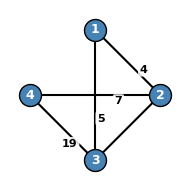

In [27]:
drawGraph(4, [(1, 2, 4), (2, 3), (1, 3, 5), (4, 3, 19), (4,2, 7)])

### Adjacency matrix

**Def.:** let the adjacency matrix of a given graph be conceptually identical to that of a simple graph, but instead of having binary entries, $a_{ij}=deg(v_iv_j)$, where this is the degree of the edge connecting the two nodes. A given node can now also be connected to itself an arbitrary number of times.Ç

**Note:** this definition of $A$ is the natural generalization of the adjacency matrix of a simple graph. Note, however, that 2 out of its 3 defining properties are gone: it is still symmetric, but its entries are no longer binary and its diagonal is no longer 0

### Groups?

**Note:** the most direct attempt at a generalization of the group action $\odot=+\text{mod 2}$ for multigraphs is ordinary matrix addition

**Theorem:** the (infinite) set of all $n$-dimensional multigraphs does NOT form a group under matrix addition

**Proof:**

There is no inverse element for every graph. In fact, there is no inverse element for any graph except for the empty graph$_\blacksquare$